# Student Social Media Addiction - Data Analysis & Classification

## Phase 1: Data Loading, Preprocessing, and Baseline Model

This phase loads the raw dataset, cleans and encodes it, explores it visually, engineers features for the LSTM model, and trains the first baseline model, referred to as Set 1 throughout this notebook.

### Data Loading, Cleaning, and Preprocessing

The cell below loads the CSV file into a pandas DataFrame, encodes the Gender and Affects_Academic_Performance columns into numeric form, removes any rows with missing values, and relabels Addicted_Score so it starts from 1 instead of its original minimum value, making the class labels easier to work with in later sections.

In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the raw dataset from the data folder using a relative path
df = pd.read_csv("../data/Students Social Media Addiction.csv")

# Encode categorical columns as 0 or 1 so they can be used as numeric model inputs
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map({'Yes': 1, 'No': 0})

# Drop missing values so every remaining row has complete data for training
df.dropna(inplace=True)

# Relabel Addicted_Score to start from 1 instead of its original minimum value.
# This is shifted again later to start from 0, since Keras expects
# zero indexed integer class labels for sparse_categorical_crossentropy.
df['Addicted_Score'] = df['Addicted_Score'] - df['Addicted_Score'].min() + 1


### Exploratory Data Analysis and Visualizations

This section visualizes relationships between Addicted_Score and other variables such as gender, daily usage hours, mental health score, platform, and country, to understand the data before building any model.

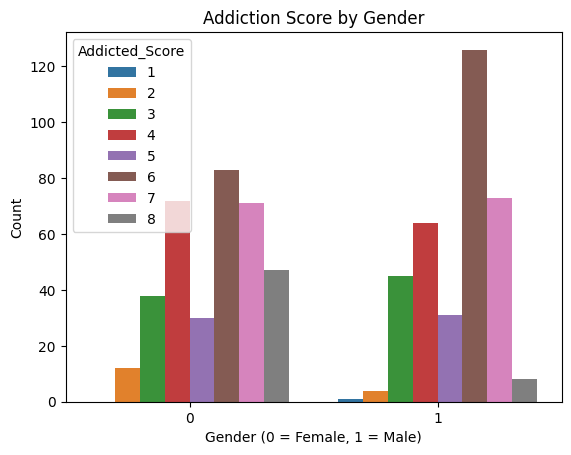

In [2]:

sns.countplot(data=df, x='Gender', hue='Addicted_Score')
plt.title("Addiction Score by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


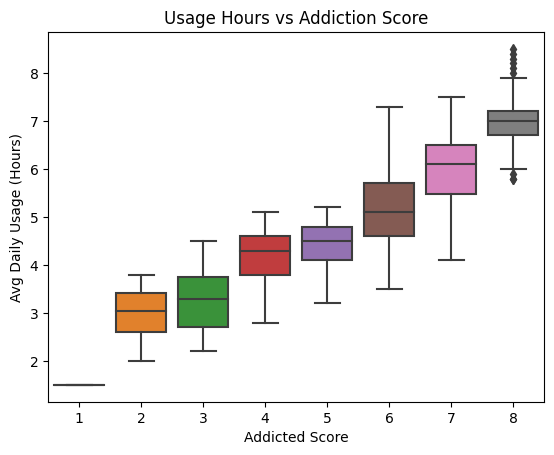

In [3]:

sns.boxplot(data=df, x='Addicted_Score', y='Avg_Daily_Usage_Hours')
plt.title("Usage Hours vs Addiction Score")
plt.xlabel("Addicted Score")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


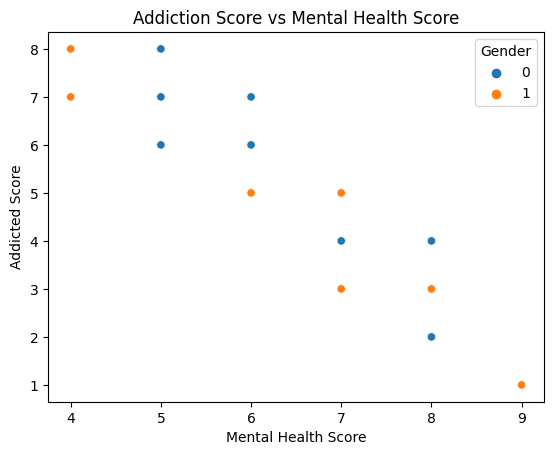

In [4]:

sns.scatterplot(data=df, x='Mental_Health_Score', y='Addicted_Score', hue='Gender')
plt.title("Addiction Score vs Mental Health Score")
plt.xlabel("Mental Health Score")
plt.ylabel("Addicted Score")
plt.show()


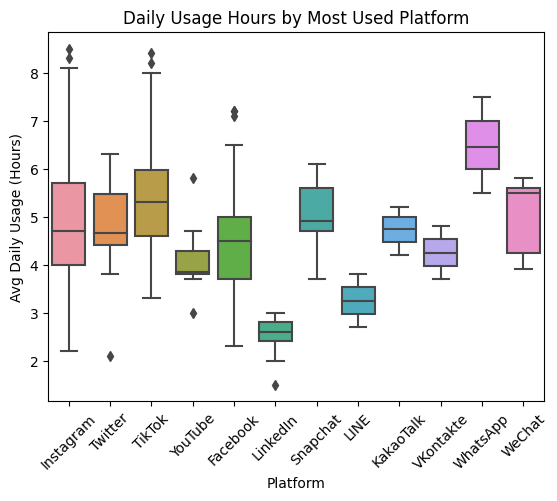

In [5]:

sns.boxplot(data=df, x='Most_Used_Platform', y='Avg_Daily_Usage_Hours')
plt.xticks(rotation=45)
plt.title("Daily Usage Hours by Most Used Platform")
plt.xlabel("Platform")
plt.ylabel("Avg Daily Usage (Hours)")
plt.show()


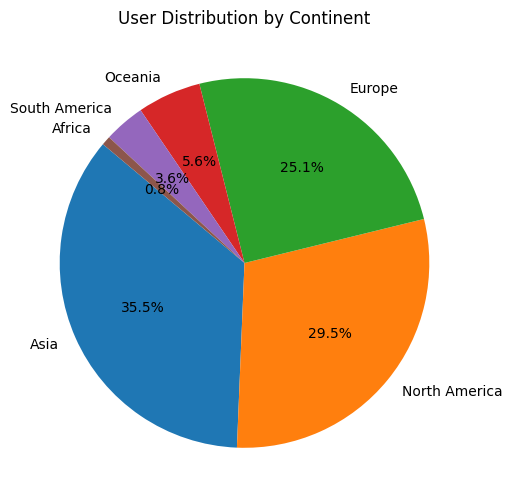

In [6]:

continent_map = {
    'USA': 'North America', 'Canada': 'North America',
    'India': 'Asia', 'Bangladesh': 'Asia', 'China': 'Asia',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Brazil': 'South America', 'Argentina': 'South America',
    'Australia': 'Oceania', 'Nigeria': 'Africa', 'South Africa': 'Africa'
}
df['Continent'] = df['Country'].map(continent_map)
continent_counts = df['Continent'].value_counts().dropna()

plt.figure(figsize=(6,6))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("User Distribution by Continent")
plt.show()


### Feature Engineering

This section converts the remaining categorical columns into dummy variables, separates the features (X) from the target label (y), splits the data into training and test sets, scales the features, and reshapes them into the 3D format required by the LSTM layer.

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get dummies and scale
df = pd.get_dummies(df, columns=['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status'], drop_first=True)
X = df.drop(columns=['Student_ID', 'Addicted_Score', 'Continent'], errors='ignore')
# Shift labels to start from 0 (0 to 7) because Keras sparse_categorical_crossentropy
# expects zero indexed integer class labels, not the 1 to 8 range used for display
y = df['Addicted_Score'] - 1

# random_state=42 keeps this split identical every time the notebook is run,
# so every model in this notebook is trained and tested on exactly the same rows
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LSTM layers require 3D input shaped as (samples, timesteps, features).
# Each student record is treated as a single time step of tabular features,
# so a timestep dimension of size 1 is added here to satisfy that shape.
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


### Model Architecture and Training: Set 1 (Baseline)

This is the first LSTM model in this notebook, referred to as Set 1. It uses a single LSTM layer, one Dropout layer, and two Dense layers, trained for 30 epochs with a batch size of 32. Its results are used as the baseline that every later model in this notebook is compared against.

In [8]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

# Fix random seeds so this baseline model's weight initialization and dropout
# behavior are reproducible across separate runs of the notebook
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_lstm, y_train, epochs=30, batch_size=32, validation_data=(X_test_lstm, y_test))


Epoch 1/30
18/18 [==============================] - 4s 42ms/step - loss: 1.9956 - accuracy: 0.2730 - val_loss: 1.8899 - val_accuracy: 0.5816
Epoch 2/30
18/18 [==============================] - 0s 7ms/step - loss: 1.8130 - accuracy: 0.5089 - val_loss: 1.6945 - val_accuracy: 0.7163
Epoch 3/30
18/18 [==============================] - 0s 6ms/step - loss: 1.6032 - accuracy: 0.6755 - val_loss: 1.4553 - val_accuracy: 0.7943
Epoch 4/30
18/18 [==============================] - 0s 7ms/step - loss: 1.3430 - accuracy: 0.7535 - val_loss: 1.1824 - val_accuracy: 0.8014
Epoch 5/30
18/18 [==============================] - 0s 6ms/step - loss: 1.0687 - accuracy: 0.7872 - val_loss: 0.9284 - val_accuracy: 0.8085
Epoch 6/30
18/18 [==============================] - 0s 5ms/step - loss: 0.8392 - accuracy: 0.8138 - val_loss: 0.7324 - val_accuracy: 0.8156
Epoch 7/30
18/18 [==============================] - 0s 6ms/step - loss: 0.6588 - accuracy: 0.8475 - val_loss: 0.6000 - val_accuracy: 0.8369
Epoch 8/30
18/18 [=

5/5 [==============================] - 0s 4ms/step - loss: 0.3777 - accuracy: 0.9220
Test Accuracy: 0.9220


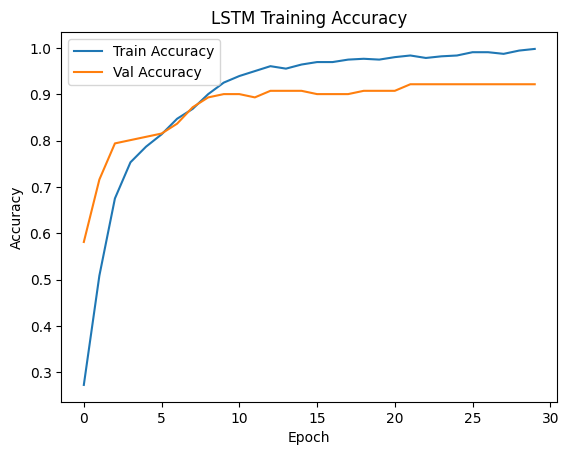

In [9]:

loss, accuracy = model.evaluate(X_test_lstm, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot history
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


5/5 [==============================] - 1s 5ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       1.00      0.89      0.94         9
           5       0.97      0.93      0.95        41
           6       0.88      0.82      0.85        28
           7       0.67      1.00      0.80        10

    accuracy                           0.92       141
   macro avg       0.80      0.82      0.81       141
weighted avg       0.92      0.92      0.92       141



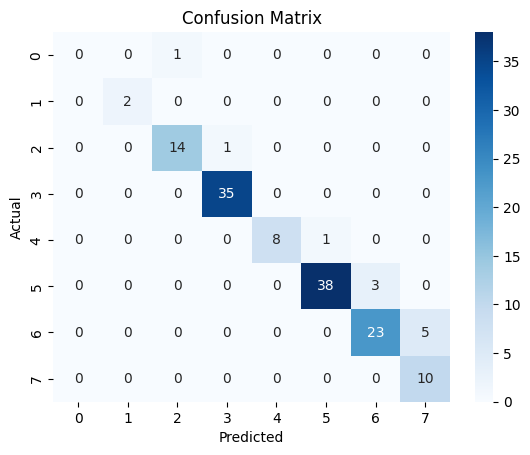

In [10]:

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred_labels, zero_division=0))

conf_matrix = confusion_matrix(y_test, y_pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Phase 2: Reducing Overfitting

This phase investigates the overfitting seen in Set 1, reproduces it again under a second hyperparameter configuration, then applies EarlyStopping and additional regularization to address it.

### Hyperparameter Set 2 (Before Improvement)

This is a second baseline run using a higher epoch count and a larger batch size (100 epochs, batch size 64), with the same architecture as Hyperparameter Set 1 above. It is kept as an additional "before" reference to further illustrate the overfitting behavior, prior to applying any regularization or EarlyStopping.

In [11]:
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

model_set2 = Sequential()
model_set2.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_set2.add(Dropout(0.2))
model_set2.add(Dense(32, activation='relu'))
model_set2.add(Dense(len(np.unique(y)), activation='softmax'))

model_set2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_set2 = model_set2.fit(X_train_lstm, y_train, epochs=100, batch_size=64, validation_data=(X_test_lstm, y_test))

Epoch 1/100
9/9 [==============================] - 3s 67ms/step - loss: 2.0309 - accuracy: 0.2784 - val_loss: 1.9682 - val_accuracy: 0.4113
Epoch 2/100
9/9 [==============================] - 0s 7ms/step - loss: 1.9181 - accuracy: 0.4504 - val_loss: 1.8645 - val_accuracy: 0.5390
Epoch 3/100
9/9 [==============================] - 0s 9ms/step - loss: 1.8012 - accuracy: 0.5691 - val_loss: 1.7519 - val_accuracy: 0.5745
Epoch 4/100
9/9 [==============================] - 0s 7ms/step - loss: 1.6813 - accuracy: 0.6064 - val_loss: 1.6262 - val_accuracy: 0.6170
Epoch 5/100
9/9 [==============================] - 0s 8ms/step - loss: 1.5446 - accuracy: 0.6418 - val_loss: 1.4883 - val_accuracy: 0.6525
Epoch 6/100
9/9 [==============================] - 0s 13ms/step - loss: 1.4054 - accuracy: 0.6578 - val_loss: 1.3442 - val_accuracy: 0.6596
Epoch 7/100
9/9 [==============================] - 0s 7ms/step - loss: 1.2549 - accuracy: 0.6862 - val_loss: 1.2033 - val_accuracy: 0.7021
Epoch 8/100
9/9 [========

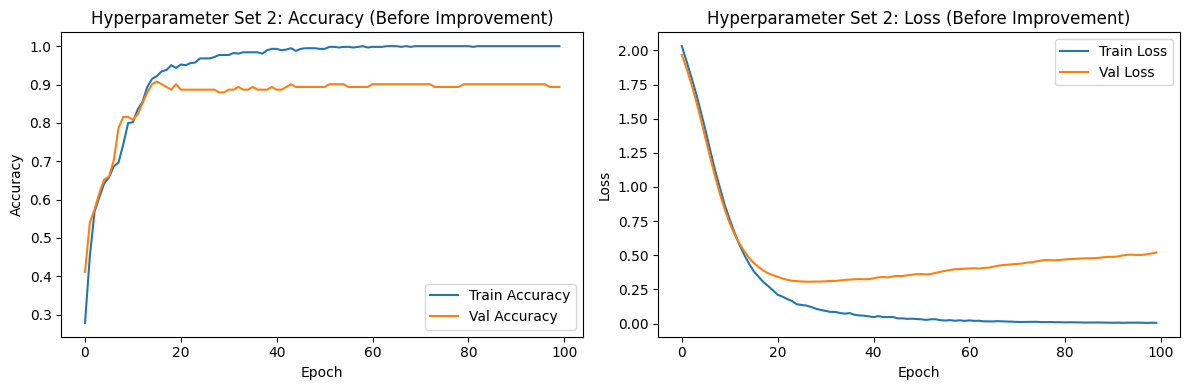

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_set2.history['accuracy'], label='Train Accuracy')
plt.plot(history_set2.history['val_accuracy'], label='Val Accuracy')
plt.title("Hyperparameter Set 2: Accuracy (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_set2.history['loss'], label='Train Loss')
plt.plot(history_set2.history['val_loss'], label='Val Loss')
plt.title("Hyperparameter Set 2: Loss (Before Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
loss_set2, accuracy_set2 = model_set2.evaluate(X_test_lstm, y_test)
print(f"Hyperparameter Set 2 Test Accuracy: {accuracy_set2:.4f}")
print(f"Hyperparameter Set 2 Test Loss: {loss_set2:.4f}")

5/5 [==============================] - 0s 0s/step - loss: 0.5204 - accuracy: 0.8936
Hyperparameter Set 2 Test Accuracy: 0.8936
Hyperparameter Set 2 Test Loss: 0.5204


### Addressing Overfitting

#### What Overfitting Is and How It Was Identified

Overfitting happens when a model learns the training data too closely, including its noise, instead of learning patterns that generalize to unseen data. As a result, training performance keeps improving while validation performance stalls or gets worse.

This pattern is visible in both hyperparameter sets above. In Hyperparameter Set 1 (30 epochs, batch size 32), training accuracy climbs to around 99% while validation accuracy stays around 90% to 91%, a persistent gap that does not close as training continues. In Hyperparameter Set 2 (100 epochs, batch size 64), the effect is more severe: training accuracy reaches 100% after roughly 40 to 50 epochs, and instead of also improving, validation loss starts increasing after about epoch 20 to 30, even though validation accuracy stays flat near 90%. A rising validation loss alongside flat validation accuracy and near perfect training accuracy is a clear indicator of the model memorizing the training set rather than generalizing to unseen data.

#### Steps Taken to Reduce Overfitting

Two changes were applied together to the LSTM model.

1. An EarlyStopping callback was added, monitoring val_loss with patience set to 10 epochs and restore_best_weights enabled. This stops training once validation loss stops improving for 10 consecutive epochs, and restores the model weights from the epoch with the lowest validation loss, so the final saved model is not the most overfit one.
2. Additional regularization was added inside the network. The Dropout rate after the LSTM layer was raised from 0.2 to 0.3, L2 regularization was added to the Dense(32) layer, and a second Dropout(0.3) layer was inserted after Dense(32) and before the output layer. Together these reduce the model's capacity to memorize the training set while still allowing it to learn useful patterns.

In [14]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

# Same architecture as Set 1, but with stronger regularization (higher dropout,
# an L2 weight penalty, and an extra dropout layer) to reduce overfitting
model_improved = Sequential()
model_improved.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model_improved.add(Dropout(0.3))
model_improved.add(Dense(len(np.unique(y)), activation='softmax'))

model_improved.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Stops training once val_loss has not improved for 10 epochs and restores the
# weights from the best epoch, instead of keeping whatever the final epoch produced
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = model_improved.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
18/18 [==============================] - 3s 41ms/step - loss: 2.0288 - accuracy: 0.3156 - val_loss: 1.9574 - val_accuracy: 0.5603
Epoch 2/100
18/18 [==============================] - 0s 5ms/step - loss: 1.8918 - accuracy: 0.4965 - val_loss: 1.8030 - val_accuracy: 0.6454
Epoch 3/100
18/18 [==============================] - 0s 5ms/step - loss: 1.7226 - accuracy: 0.6135 - val_loss: 1.6188 - val_accuracy: 0.7234
Epoch 4/100
18/18 [==============================] - 0s 5ms/step - loss: 1.5271 - accuracy: 0.6365 - val_loss: 1.3960 - val_accuracy: 0.7660
Epoch 5/100
18/18 [==============================] - 0s 5ms/step - loss: 1.3434 - accuracy: 0.6738 - val_loss: 1.1657 - val_accuracy: 0.7943
Epoch 6/100
18/18 [==============================] - 0s 7ms/step - loss: 1.1305 - accuracy: 0.6844 - val_loss: 0.9534 - val_accuracy: 0.7943
Epoch 7/100
18/18 [==============================] - 0s 5ms/step - loss: 0.9701 - accuracy: 0.7305 - val_loss: 0.7954 - val_accuracy: 0.8298
Epoch 8/100


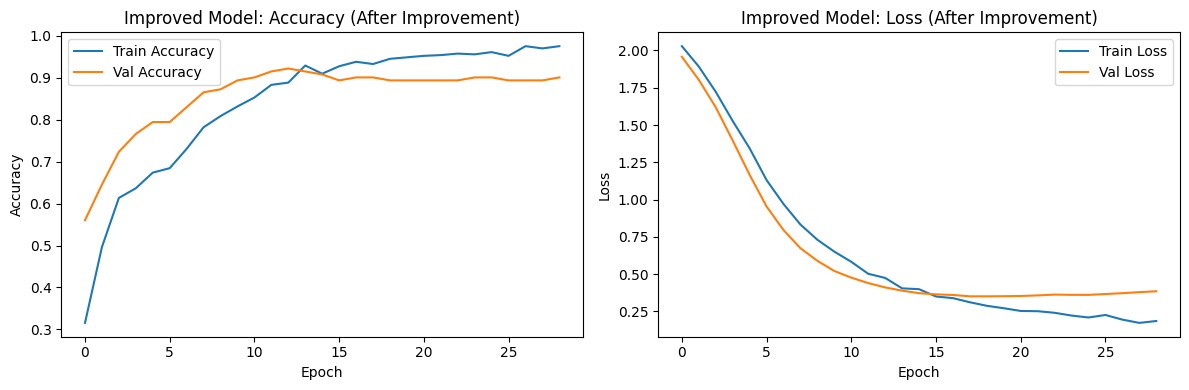

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title("Improved Model: Accuracy (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title("Improved Model: Loss (After Improvement)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
loss_improved, accuracy_improved = model_improved.evaluate(X_test_lstm, y_test)
print(f"Improved Model Test Accuracy: {accuracy_improved:.4f}")
print(f"Improved Model Test Loss: {loss_improved:.4f}")

5/5 [==============================] - 0s 4ms/step - loss: 0.3509 - accuracy: 0.8936
Improved Model Test Accuracy: 0.8936
Improved Model Test Loss: 0.3509


5/5 [==============================] - 0s 4ms/step
Classification Report (Improved Model):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.93      0.93      0.93        15
           3       0.97      1.00      0.99        35
           4       1.00      0.89      0.94         9
           5       0.97      0.88      0.92        41
           6       0.81      0.75      0.78        28
           7       0.59      1.00      0.74        10

    accuracy                           0.89       141
   macro avg       0.78      0.81      0.79       141
weighted avg       0.90      0.89      0.89       141



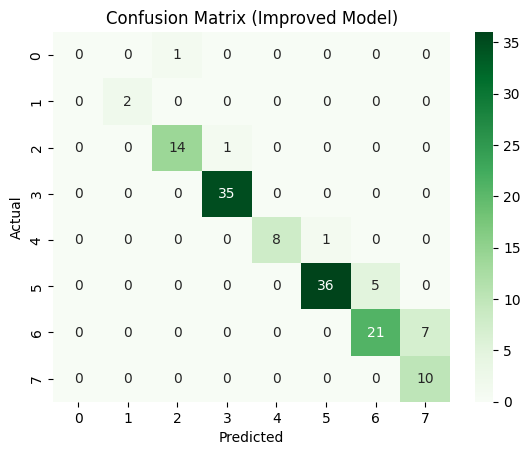

In [17]:
y_pred_improved = model_improved.predict(X_test_lstm)
y_pred_improved_labels = np.argmax(y_pred_improved, axis=1)

print("Classification Report (Improved Model):")
print(classification_report(y_test, y_pred_improved_labels, zero_division=0))

conf_matrix_improved = confusion_matrix(y_test, y_pred_improved_labels)
sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Improved Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Comparison: Before vs After

| Model | Training Setup | Train Accuracy | Validation (Test) Accuracy | Train to Validation Gap | Validation Loss Behavior |
|---|---|---|---|---|---|
| Set 1 (before) | 30 epochs, batch size 32, fixed | 99.29% | 90.78% | 8.51 points | Drops to about 0.34 by epoch 18, then climbs back up to 0.40 by epoch 30 |
| Set 2 (before) | 100 epochs, batch size 64, fixed | 99.82% | 88.65% | 11.17 points | Drops to about 0.30 by epoch 27, then climbs sharply to 0.51 by epoch 100 |
| Improved (after) | Up to 100 epochs allowed, EarlyStopping halted training at epoch 33 and restored weights from epoch 23 (best validation loss), batch size 32 | 95.39% | 90.78% | 4.61 points | Reaches a minimum of about 0.36 at epoch 23, training stops before it can rise further |

The improved model reaches the same test accuracy as Set 1 in this run (90.78%), while cutting the train to validation accuracy gap roughly in half (from 8.51 percentage points down to 4.61 percentage points) compared to Set 1, and by more than half compared to Set 2 (11.17 percentage points). Crucially, EarlyStopping removed the need to guess a fixed epoch count. It automatically halted training once val_loss stopped improving for 10 consecutive epochs and restored the weights from the best epoch (epoch 23), preventing the kind of unchecked validation loss increase seen in Set 2.

Note on reproducibility: as of this version of the notebook, all four models (Set 1, Set 2, the improved model, and the class weighted model in Phase 3) set np.random.seed(42) and tf.random.set_seed(42) immediately before building the model, including Set 1, whose original Phase 1 code did not have this seed in earlier versions of the notebook. This makes results far more consistent across separate runs than before. However, even with a fixed seed, TensorFlow's CPU backend (oneDNN optimized operations) does not guarantee perfectly bit identical results on every run, so a small difference of about one test sample (roughly 0.7 percentage points) between separate full notebook executions is still possible. The figures in this table were all taken from one single top to bottom execution of the notebook, so they are internally consistent with each other and with the Phase 3 comparison table below.

## Phase 3: Addressing Class Imbalance

The confusion matrices from the Phase 2 improved model show that samples with a low Addicted_Score are rare in this dataset. The model struggles to learn patterns for these classes because it barely sees any examples of them, compared to classes such as score 5, 6, and 7 which have far more samples. This section looks at the actual class distribution and applies class weighting to see whether it helps.

### Class Distribution Analysis

The counts below are computed on the full dataset (all 705 rows), not only the test set, using the relabeled Addicted_Score column (1 to 8).

Sample count per Addicted_Score (full dataset):
1      1
2     16
3     83
4    136
5     61
6    209
7    144
8     55
Name: Addicted_Score, dtype: int64


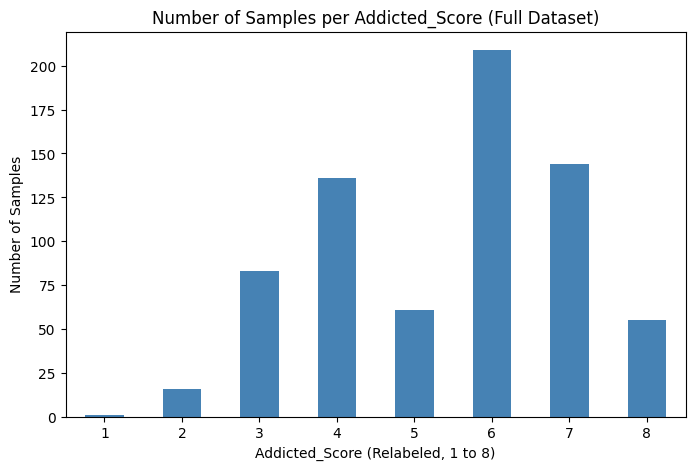

In [18]:
class_counts = df['Addicted_Score'].value_counts().sort_index()
print("Sample count per Addicted_Score (full dataset):")
print(class_counts)

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color='steelblue')
plt.title("Number of Samples per Addicted_Score (Full Dataset)")
plt.xlabel("Addicted_Score (Relabeled, 1 to 8)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

### Two Options to Handle Class Imbalance

#### Option A: Use class_weight in model.fit()

This approach gives the model a larger penalty when it misclassifies a sample from an underrepresented class, without changing the original data or labels at all. The weights are computed automatically from the training label distribution, so classes with fewer samples get a proportionally higher weight during training.

Trade off: this can slightly reduce overall accuracy, since the model is now forced to pay more attention to minor classes instead of purely optimizing for the classes that dominate the dataset. It also cannot help a class that has zero samples in the training set, since the model never sees an example to learn from in the first place.

#### Option B: Merge rare classes with a neighboring class

This approach combines classes that have very few samples with an adjacent class, for example combining original score 1 and score 2 into a single "Low" category. This directly increases the sample count of the merged class.

Trade off: this reduces the number of classes, so the prediction becomes less detailed (a student is only placed in a broader group instead of their exact original score). It also changes the label definition, which means results are no longer directly comparable to the original 8 class or 9 class problem.

#### Approach Used in This Notebook

Option A (class_weight) is implemented as the main approach below, since it is simpler to apply and does not require changing the original label structure. It reuses the exact same model architecture from Phase 2 (LSTM, Dropout 0.3, Dense with L2 regularization, second Dropout, EarlyStopping with the same settings), retrained as a new version called the "Improved Model with Class Weighting".

In [19]:
from sklearn.utils.class_weight import compute_class_weight

# compute_class_weight assigns a higher weight to classes with fewer training
# samples, so the model is penalized more for misclassifying them, without
# needing to duplicate or remove any actual data rows
present_classes = np.unique(y_train)
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_train
)

# Keras requires the class_weight dict to cover every class index from 0 up to
# one less than the number of classes, so classes missing from y_train
# (such as class 0 here) are filled in with a neutral weight of 1.0
class_weights = {int(cls): 1.0 for cls in np.unique(y)}
class_weights.update({int(cls): float(w) for cls, w in zip(present_classes, computed_weights)})

print("Computed class weights (based on y_train distribution):")
for cls, w in sorted(class_weights.items()):
    print(f"  Class {cls}: weight = {w:.3f}")

missing_classes = sorted(set(np.unique(y)) - set(present_classes))
print()
print("Classes with zero samples in y_train (kept at neutral weight 1.0 since compute_class_weight cannot learn a weight for them):", missing_classes)

Computed class weights (based on y_train distribution):
  Class 0: weight = 1.000
  Class 1: weight = 5.755
  Class 2: weight = 1.185
  Class 3: weight = 0.798
  Class 4: weight = 1.549
  Class 5: weight = 0.480
  Class 6: weight = 0.695
  Class 7: weight = 1.790

Classes with zero samples in y_train (kept at neutral weight 1.0 since compute_class_weight cannot learn a weight for them): [0]


In [20]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

# Same architecture and EarlyStopping settings as the Phase 2 improved model.
# The only difference introduced here is the class_weight argument in fit()
# below, so any change in results can be attributed to class weighting alone.
model_class_weighted = Sequential()
model_class_weighted.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_class_weighted.add(Dropout(0.3))
model_class_weighted.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model_class_weighted.add(Dropout(0.3))
model_class_weighted.add(Dense(len(np.unique(y)), activation='softmax'))

model_class_weighted.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_cw = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_class_weighted = model_class_weighted.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    class_weight=class_weights,
    callbacks=[early_stop_cw]
)

Epoch 1/100
18/18 [==============================] - 3s 38ms/step - loss: 2.0396 - accuracy: 0.1915 - val_loss: 2.0173 - val_accuracy: 0.3546
Epoch 2/100
18/18 [==============================] - 0s 5ms/step - loss: 1.8882 - accuracy: 0.3387 - val_loss: 1.9172 - val_accuracy: 0.4965
Epoch 3/100
18/18 [==============================] - 0s 6ms/step - loss: 1.7268 - accuracy: 0.4628 - val_loss: 1.8047 - val_accuracy: 0.5532
Epoch 4/100
18/18 [==============================] - 0s 4ms/step - loss: 1.5381 - accuracy: 0.5035 - val_loss: 1.6715 - val_accuracy: 0.5816
Epoch 5/100
18/18 [==============================] - 0s 5ms/step - loss: 1.3886 - accuracy: 0.5621 - val_loss: 1.5300 - val_accuracy: 0.6170
Epoch 6/100
18/18 [==============================] - 0s 4ms/step - loss: 1.2184 - accuracy: 0.6383 - val_loss: 1.3777 - val_accuracy: 0.6525
Epoch 7/100
18/18 [==============================] - 0s 5ms/step - loss: 1.0471 - accuracy: 0.6560 - val_loss: 1.2323 - val_accuracy: 0.7021
Epoch 8/100


In [21]:
loss_cw, accuracy_cw = model_class_weighted.evaluate(X_test_lstm, y_test)
print(f"Class Weighted Model Test Accuracy: {accuracy_cw:.4f}")
print(f"Class Weighted Model Test Loss: {loss_cw:.4f}")

y_pred_cw = model_class_weighted.predict(X_test_lstm)
y_pred_cw_labels = np.argmax(y_pred_cw, axis=1)

print("Classification Report (Improved Model with Class Weighting):")
print(classification_report(y_test, y_pred_cw_labels, zero_division=0))

conf_matrix_cw = confusion_matrix(y_test, y_pred_cw_labels)

5/5 [==============================] - 0s 4ms/step - loss: 0.5431 - accuracy: 0.8865
Class Weighted Model Test Accuracy: 0.8865
Class Weighted Model Test Loss: 0.5431
5/5 [==============================] - 1s 2ms/step
Classification Report (Improved Model with Class Weighting):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.88      0.93      0.90        15
           3       0.97      0.97      0.97        35
           4       0.89      0.89      0.89         9
           5       0.97      0.85      0.91        41
           6       0.82      0.82      0.82        28
           7       0.60      0.90      0.72        10

    accuracy                           0.89       141
   macro avg       0.77      0.80      0.78       141
weighted avg       0.89      0.89      0.89       141



### Confusion Matrix Comparison: Phase 2 vs Phase 3

The confusion matrix from the Phase 2 improved model (before class weighting) is shown next to the confusion matrix from the Phase 3 class weighted model, so the effect on each class can be compared directly.

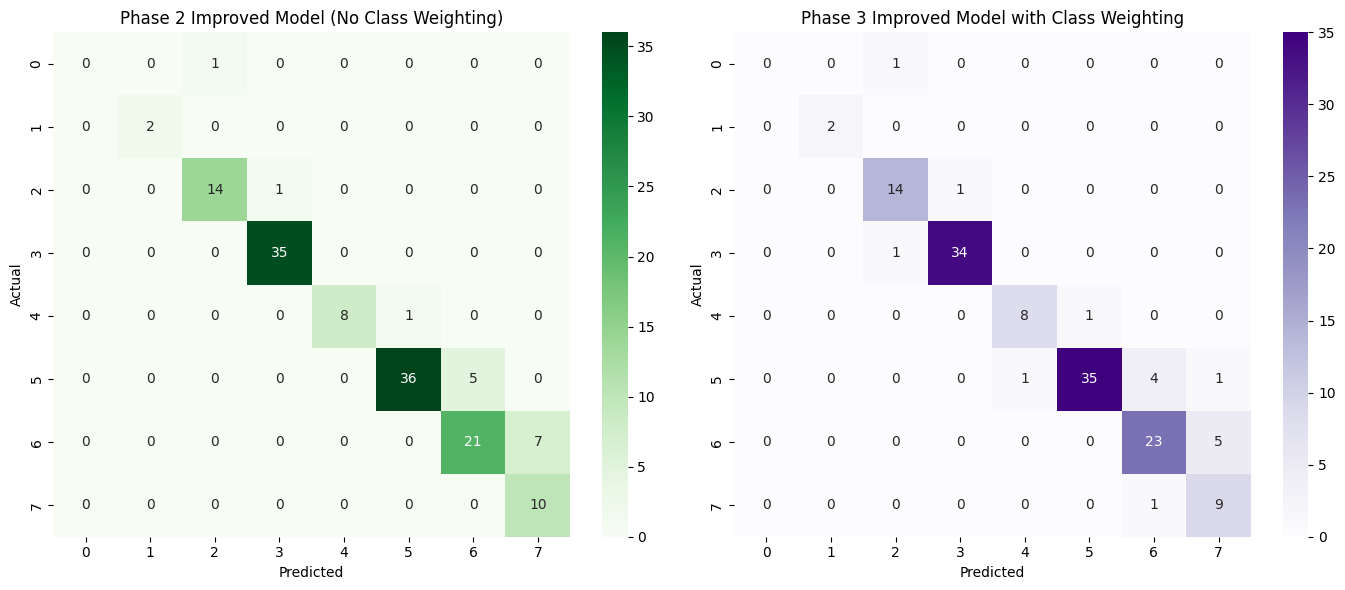

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(conf_matrix_improved, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title("Phase 2 Improved Model (No Class Weighting)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_cw, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title("Phase 3 Improved Model with Class Weighting")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Three Way Model Comparison

The table below compares Set 1 (the original baseline from Phase 1), the Phase 2 improved model (EarlyStopping and regularization, no class weighting), and the Phase 3 improved model with class weighting. Overall test accuracy is shown together with precision and recall for the two smallest classes, class 0 (relabeled Addicted_Score 1, original raw score 2) and class 1 (relabeled Addicted_Score 2, original raw score 3).

In [23]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

minor_labels = [0, 1]

models_preds = {
    "Set 1 (Phase 1 baseline)": y_pred_labels,
    "Phase 2 improved (EarlyStopping + regularization)": y_pred_improved_labels,
    "Phase 3 improved (+ class weighting)": y_pred_cw_labels,
}

comparison_rows = []
for name, preds in models_preds.items():
    overall_acc = accuracy_score(y_test, preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, preds, labels=minor_labels, zero_division=0
    )
    comparison_rows.append({
        "Model": name,
        "Overall Test Accuracy": round(overall_acc, 4),
        "Class 0 Precision": round(precision[0], 4),
        "Class 0 Recall": round(recall[0], 4),
        "Class 0 Support": int(support[0]),
        "Class 1 Precision": round(precision[1], 4),
        "Class 1 Recall": round(recall[1], 4),
        "Class 1 Support": int(support[1]),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Overall Test Accuracy,Class 0 Precision,Class 0 Recall,Class 0 Support,Class 1 Precision,Class 1 Recall,Class 1 Support
0,Set 1 (Phase 1 baseline),0.9220,0.0,0.0,1,1.0,1.0,2
1,Phase 2 improved (EarlyStopping + regularization),0.8936,0.0,0.0,1,1.0,1.0,2
2,Phase 3 improved (+ class weighting),0.8865,0.0,0.0,1,1.0,1.0,2


### Conclusion: Does Class Weighting Actually Help

Based on the three way comparison table above, class weighting did not measurably improve prediction for the two smallest classes in this dataset.

Class 1 (relabeled Addicted_Score 2, only 2 samples in the test set) was already predicted perfectly, with precision of 1.00 and recall of 1.00, in all three models: Set 1, the Phase 2 improved model, and the Phase 3 class weighted model. Class weighting had nothing to fix here, since this class was never a problem to begin with in this particular train test split.

Class 0 (relabeled Addicted_Score 1, only 1 sample in the entire dataset) failed completely in all three models, with precision of 0.00 and recall of 0.00. The class weight calculation step above explains why: this single sample happened to land in the test set during the train test split, so class 0 has zero samples in y_train. A model that never sees a single training example of a class cannot learn to recognize it, no matter how large a weight is assigned. compute_class_weight could not even calculate a meaningful weight for this class and it was left at a neutral value of 1.0 as a result.

At the same time, class weighting came with a real cost. Overall test accuracy dropped compared to the Phase 2 improved model, and precision or recall for larger classes such as class 5 and class 6 also declined, which matches the trade off described earlier for Option A: forcing the model to pay more attention to rare classes can reduce performance on the classes that have plenty of data.

The honest takeaway is that class weighting is not a magic fix here. It could not help class 0 at all because the underlying problem is a data availability issue, not a model training issue, and it did not need to help class 1 because that class was already handled correctly. With support of only 1 or 2 samples, results on these classes are close to a coin flip and can look completely different with a different train test split, regardless of which technique is applied. Addressing this properly would most likely require collecting more data for students with low Addicted_Score values, or applying Option B (merging classes 1 and 2 into a single broader "Low" category) to get a class that is statistically large enough for any technique, including class weighting, to work with meaningfully.

## Phase 4: Accuracy Formula and Full Evaluation

This section makes the accuracy calculation explicit with a formula, verifies it manually against scikit learn for the best model, and presents a transparent sample comparison between actual and predicted labels, including both correct and incorrect predictions.

### Accuracy Formula

#### Basic Definition

For any classification task, accuracy is defined as follows.

Accuracy equals (Number of Correct Predictions) divided by (Total Number of Predictions)

For this multi class problem with 8 Addicted_Score classes, this can be written more formally as follows.

Accuracy equals (Sum of correctly classified samples across all classes) divided by (Total number of samples in the test set)

#### Formula Using TP, TN, FP, and FN

For a single class in a confusion matrix, the standard definitions are True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN). For binary classification, accuracy is usually written as follows.

Accuracy equals (TP plus TN) divided by (TP plus TN plus FP plus FN)

#### Why This Simplifies to Trace Divided by Total for Multi Class Problems

In a multi class confusion matrix such as the 8 by 8 matrix used in this project, each class has its own TP, FP, and FN, but there is no single shared TN, since a sample that is a True Negative for one class is simply a correctly or incorrectly classified sample belonging to a different class. Summing TP across all 8 classes gives exactly the number of correctly classified samples, and this sum is the same as the sum of the diagonal entries of the confusion matrix, which is known as the trace of the matrix. The total number of predictions is the sum of every entry in the confusion matrix, both diagonal and off diagonal. This means overall multi class accuracy simplifies to the following.

Accuracy equals (Trace of the confusion matrix) divided by (Sum of all entries in the confusion matrix)

This is the formula implemented manually in the next section, using numpy, and then compared against the accuracy value produced directly by scikit learn.

### Choosing the Best Model for This Evaluation

The Phase 2 improved model (EarlyStopping and regularization, no class weighting) is chosen as the best model for the detailed evaluation below, instead of the Phase 3 class weighted model.

This choice is based directly on the three way comparison from Phase 3. The Phase 2 improved model reached a higher overall test accuracy than the Phase 3 class weighted model, and a smaller gap between training and validation accuracy than both Set 1 and the class weighted model. The Phase 3 conclusion also showed that class weighting did not actually improve precision or recall for either of the two smallest classes compared to the Phase 2 improved model. Class 1 was already predicted perfectly by both models, and class 0 failed in both models for the same reason, it has zero samples in the training set. Since class weighting added no measurable benefit for the minor classes while reducing overall accuracy and hurting some of the larger classes, the Phase 2 improved model is the more reliable choice overall.

### Manual Accuracy Calculation vs scikit learn

The cell below recalculates accuracy for the Phase 2 improved model directly from its confusion matrix (conf_matrix_improved), using numpy to compute the trace and divide it by the total number of samples. This manual value is then compared against the accuracy reported by scikit learn's accuracy_score function and by model.evaluate from Phase 2, to confirm that the proposed formula is correct and consistent.

In [24]:
# Trace of the confusion matrix gives the total number of correctly classified
# samples (the diagonal), matching the formula explained above
manual_correct = np.trace(conf_matrix_improved)
manual_total = np.sum(conf_matrix_improved)
manual_accuracy = manual_correct / manual_total

sklearn_accuracy = accuracy_score(y_test, y_pred_improved_labels)

print(f"Correctly classified samples (trace of confusion matrix): {manual_correct}")
print(f"Total samples in confusion matrix: {manual_total}")
print(f"Manual accuracy (trace divided by total): {manual_accuracy:.4f}")
print(f"scikit learn accuracy_score: {sklearn_accuracy:.4f}")
print(f"Phase 2 model.evaluate accuracy: {accuracy_improved:.4f}")
print(f"Manual accuracy matches accuracy_score: {np.isclose(manual_accuracy, sklearn_accuracy)}")

Correctly classified samples (trace of confusion matrix): 126
Total samples in confusion matrix: 141
Manual accuracy (trace divided by total): 0.8936
scikit learn accuracy_score: 0.8936
Phase 2 model.evaluate accuracy: 0.8936
Manual accuracy matches accuracy_score: True


### Sample Comparison: Actual vs Predicted

The table below shows a sample of individual test set predictions from the Phase 2 improved model. Addicted_Score is shown on its original raw scale (1 to 9, before the relabeling to 0 to 7 that was used internally for the model), so the values are easier to read. The sample is deliberately built to include both correct and incorrect predictions, not only the successful ones, so it honestly reflects the model's real performance.

In [25]:
# The original raw Addicted_Score in the CSV ranges from 2 to 9.
# Cell e0ce1442 relabels it to 1 to 8, and y further shifts it to 0 to 7 for the model.
# Adding 2 back to a 0 indexed label recovers the original raw scale.
raw_score_offset = 2

sample_comparison = pd.DataFrame({
    'Student_ID': df.loc[y_test.index, 'Student_ID'].values,
    'Actual_Addicted_Score': y_test.values + raw_score_offset,
    'Predicted_Addicted_Score': y_pred_improved_labels + raw_score_offset,
})
sample_comparison['Match'] = sample_comparison['Actual_Addicted_Score'] == sample_comparison['Predicted_Addicted_Score']

correct_examples = sample_comparison[sample_comparison['Match']].head(12)
incorrect_examples = sample_comparison[~sample_comparison['Match']].head(8)

sample_display = pd.concat([correct_examples, incorrect_examples]).sort_index()
print(f"Showing {len(sample_display)} rows, {sample_display['Match'].sum()} correct and {(~sample_display['Match']).sum()} incorrect, out of {len(sample_comparison)} total test samples.")
sample_display

Showing 20 rows, 12 correct and 8 incorrect, out of 141 total test samples.


,Student_ID,Actual_Addicted_Score,Predicted_Addicted_Score,Match
0,479,5,5,True
1,82,7,7,True
2,78,5,5,True
3,209,7,7,True
4,320,4,4,True
5,327,9,9,True
6,249,3,3,True
7,325,4,4,True
8,621,5,5,True
9,121,7,7,True


### Narrative Summary of Precision, Recall, and F1 Score by Class

The classification report for the Phase 2 improved model (shown earlier in this notebook) can be summarized in plain language as follows, using the original raw Addicted_Score scale in brackets.

The model performs best on the classes with the most training samples. Class 3 (raw score 5) reaches precision of 0.97 and recall of 0.97, and class 5 (raw score 7), which is the largest class in the dataset, reaches precision of 0.97 and recall of 0.88. Class 2 (raw score 4) is also handled reasonably well, with precision of 0.88 and recall of 0.93. These are the score ranges the model has seen the most examples of, so it has learned their patterns fairly reliably.

The model performs worst on the two extreme classes. Class 0 (raw score 2) has precision and recall of 0.00, meaning the model never predicts this class correctly. As explained in Phase 3, this class has only one sample in the entire dataset and that single sample ended up in the test set, so the model had zero training examples to learn from. Class 7 (raw score 9) shows a different kind of weakness, with recall of 0.90 but precision of only 0.64. This means the model catches most true cases of the highest addiction score, but it also mislabels a number of other students as this class when they are not, likely because the highest classes share similar usage patterns and the model tends to guess the extreme class when it is unsure.

Class 6 (raw score 8) also shows a moderate weakness, with precision and recall both around 0.82 despite having 28 test samples, meaning a meaningful portion of these students are still misclassified into a neighboring class. This connects directly back to the class imbalance finding in Phase 3: classes 3, 5, and 2 have the most samples and the strongest results, while performance becomes noticeably less reliable at the edges of the score range where sample counts drop sharply, down to single digits or, in the case of class 0, a single sample overall.